<a href="https://colab.research.google.com/github/AgacheM/Analyzing-Toronto-Airbnb-Dataset/blob/main/CIND_820_Notebook_1_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [67]:
#Check the version of Python being run
!python --version

# Install all dependencies
!pip install pandas matplotlib seaborn ipython numpy

#Import Libraries
#Data Manipulation, Cleaning, and Analysis
import pandas as pd
import numpy as np

#Data Types
!pip install ydata-profiling
from ydata_profiling import ProfileReport

#Univarate Analysis
!pip install sweetviz
import sweetviz as sv

#Formatting and Visualizations
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.display import FileLink
from IPython.display import IFrame

#Format without scientific notation
pd.options.display.float_format = '{:,.0f}'.format

Python 3.12.13


# **2. Download Listings & Reviews Data from Insideairbnb.com**

In [68]:
#Import listings files
url_toronto = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/listings.csv.gz"
df_toronto = pd.read_csv(url_toronto, compression='gzip')

url_montreal = "https://data.insideairbnb.com/canada/qc/montreal/2025-09-18/data/listings.csv.gz"
df_montreal = pd.read_csv(url_montreal, compression='gzip')

url_ottawa = "https://data.insideairbnb.com/canada/on/ottawa/2025-09-22/data/listings.csv.gz"
df_ottawa = pd.read_csv(url_ottawa, compression='gzip')

#Add city labels
df_toronto['city'] = 'Toronto'
df_montreal['city'] = 'Montreal'
df_ottawa['city'] = 'Ottawa'

#Combine data
df_listings = pd.concat([df_toronto, df_montreal, df_ottawa], ignore_index=True)

#Encode city labels for future modelling
df_listings['city_code'] = df_listings['city'].map({
    'Toronto': 1,
    'Montreal': 2,
    'Ottawa': 3})

# **3. Check Common Features in Combined Datasets**

In [69]:
#Compare number of columns to ensure they are the same between cities
print("Toronto columns:", len(df_toronto.columns))
print("Montreal columns:", len(df_montreal.columns))
print("Ottawa columns:", len(df_ottawa.columns))

#Keep only the common columns, use a set to remove duplicates and ignore order of columns
common_cols = list(
    set(df_toronto.columns) &
    set(df_montreal.columns) &
    set(df_ottawa.columns))

print(f"""
Check all 3 cities' datasets contain the same column names = {set(df_toronto.columns) == set(df_ottawa.columns) == set(df_montreal.columns)}.
      """)

print(f"""The datsets of the 3 cities share these column columns: {common_cols}
      """)

#Check row counts
print(f"""The number of rows / observations in each city are:
{df_listings['city'].value_counts()}""")

Toronto columns: 80
Montreal columns: 80
Ottawa columns: 80

Check all 3 cities' datasets contain the same column names = True.
      
The datsets of the 3 cities share these column columns: ['calendar_last_scraped', 'amenities', 'last_scraped', 'host_thumbnail_url', 'host_acceptance_rate', 'review_scores_rating', 'listing_url', 'calculated_host_listings_count_private_rooms', 'host_picture_url', 'neighbourhood_cleansed', 'host_is_superhost', 'minimum_nights_avg_ntm', 'picture_url', 'license', 'host_listings_count', 'host_neighbourhood', 'review_scores_communication', 'minimum_nights', 'neighbourhood', 'review_scores_cleanliness', 'has_availability', 'maximum_minimum_nights', 'property_type', 'scrape_id', 'host_has_profile_pic', 'last_review', 'calculated_host_listings_count', 'source', 'host_location', 'neighbourhood_group_cleansed', 'minimum_minimum_nights', 'number_of_reviews', 'maximum_nights_avg_ntm', 'availability_90', 'city', 'review_scores_accuracy', 'host_response_time', 'bedro

# **4. Dataset Overview**

In [70]:
#Summarize Listings Data
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_listings.shape[0]:,}
Columns: {df_listings.shape[1]}

FIRST 5 ROWS
---------------""")
display(df_listings.head())


DATASET OVERVIEW
----------------
Rows: 33,748
Columns: 81

FIRST 5 ROWS
---------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,city_code
0,1419,https://www.airbnb.com/rooms/1419,20251111064035,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,...,5,NaN,f,1,1,0,0,0,Toronto,1
1,8077,https://www.airbnb.com/rooms/8077,20251111064035,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,...,5,NaN,f,2,1,1,0,1,Toronto,1
2,26654,https://www.airbnb.com/rooms/26654,20251111064035,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,...,5,NaN,f,3,3,0,0,0,Toronto,1
3,27423,https://www.airbnb.com/rooms/27423,20251111064035,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,...,5,NaN,f,1,1,0,0,0,Toronto,1
4,30931,https://www.airbnb.com/rooms/30931,20251111064035,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,...,NaN,NaN,f,2,1,1,0,0,Toronto,1


# **4.Basic Data Profiling of Numeric Features**
  For further analysis, please see the file [Notebook 1 - Automated Exploratory Data Analysis](https://github.com/AgacheM/Analyzing-Toronto-Airbnb-Dataset/blob/main/Notebook%201%20-%20Automated%20Exploratory%20Data%20Analysis%20-%20Data%20Types%2C%20Distributions%2C%20Skewness%2C%20and%20Correlations.ipynb)


In [71]:
#Columns, Basic Data Types, Missing values
print("OVERVIEW OF KEY NUMERICAL STATS, DATA TYPES AND MISSING VALUES \n ----------------------------------------------------------")

display(df_listings.describe())



OVERVIEW OF KEY NUMERICAL STATS, DATA TYPES AND MISSING VALUES 
 ----------------------------------------------------------


,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city_code
count,"33,748","33,748","33,748","33,730","33,730",0,"33,748","33,748","33,748","26,716",...,"26,517","26,517","26,516","26,517","33,748","33,748","33,748","33,748","26,519","33,748"
mean,"738,625,211,947,228,288","20,251,041,151,264","250,423,480",11,17,NaN,44,-77,3,1,...,5,5,5,5,8,6,2,0,2,1
std,"582,636,723,054,536,960","92,445,343","227,152,594",25,50,NaN,1,3,2,1,...,0,0,0,0,19,17,9,0,2,1
min,"1,419","20,250,918,041,652","1,565",1,1,NaN,44,-80,1,0,...,0,0,0,0,1,0,0,0,0,1
25%,"39,989,166","20,250,918,041,652","39,115,671",1,1,NaN,44,-79,2,1,...,5,5,5,5,1,1,0,0,0,1
50%,"892,046,136,746,028,544","20,251,111,064,035","175,185,636",2,3,NaN,44,-79,2,1,...,5,5,5,5,2,1,0,0,1,1
75%,"1,260,110,675,079,240,448","20,251,111,064,035","467,329,167",7,10,NaN,45,-74,4,2,...,5,5,5,5,6,3,1,0,2,2
max,"1,551,251,861,012,383,488","20,251,111,064,035","728,337,308",335,960,NaN,46,-73,16,20,...,5,5,5,5,141,141,118,13,62,3


# **5. Identify and Handle >50% Missing Values**

In [72]:
#Calculate Missing Values
print ("Missing Values:")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

#Correct Errors
if len(missing_summary) > 0:
    display(
        missing_summary
        .sort_values (by="Missing %", ascending= False)
        .style.format({
            "Missing Count": "{:,.0f}",
            "Missing %": "{:.2f}%"
        })
        .background_gradient(cmap="Reds")
    )
else:
    print ("No Missing Values Found")

Missing Values:


,Missing Count,Missing %
neighbourhood_group_cleansed,"33,748",100.00%
calendar_updated,"33,748",100.00%
host_neighbourhood,"21,737",64.41%
neighborhood_overview,"19,211",56.92%
neighbourhood,"19,210",56.92%
host_about,"17,656",52.32%
license,"16,812",49.82%
host_location,"8,766",25.97%
host_response_time,"8,239",24.41%
host_response_rate,"8,239",24.41%


In [73]:
#Drop features with >50% Missing values
print ("Drop features with >50% missing values")

columns_to_drop = missing_summary[missing_summary["Missing %"]>50].index
df_listings = df_listings.drop(columns=columns_to_drop)

print(f"""
Dropped {len(columns_to_drop)} columns with high missing values.
""")
print(f"""Dropped columns: {(columns_to_drop)}
      """)

print ("Remaning Missing Values:\n")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

#Correct Errors
if len(missing_summary) > 0:
    display(
        missing_summary
        .sort_values (by="Missing %", ascending= False)
        .style.format({
            "Missing Count": "{:,.0f}",
            "Missing %": "{:.2f}%"
        })
        .background_gradient(cmap="Reds")
    )
else:
    print ("No Missing Values Found")

Drop features with >50% missing values

Dropped 6 columns with high missing values.

Dropped columns: Index(['neighborhood_overview', 'host_about', 'host_neighbourhood',
       'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated'],
      dtype='object')
      
Remaning Missing Values:



,Missing Count,Missing %
license,"16,812",49.82%
host_location,"8,766",25.97%
host_response_time,"8,239",24.41%
host_response_rate,"8,239",24.41%
review_scores_location,"7,232",21.43%
review_scores_accuracy,"7,231",21.43%
review_scores_communication,"7,231",21.43%
review_scores_value,"7,231",21.43%
review_scores_checkin,"7,231",21.43%
review_scores_cleanliness,"7,230",21.42%


# **7. Manual Feature Selection: Drop Columns Containing Personally Identifiable Information (PII) or not Adding Analytical Value**

In [74]:
#The columns below will be dropped, due to  PII concerns, low variablity, or in the case of metadata, due to a lack of signifiant value in determining price

more_columns_to_drop = [
    #IDs
    'id', 'host_id', 'scrape_id',
    #URLs or Images
    'listing_url', 'host_url', 'picture_url', 'host_thumbnail_url', 'host_picture_url',
    #Text Fields
    'name', 'description', 'neighborhood_overview','host_about', 'amenities',
    #Host Info or PII
    'host_name', 'host_location', 'host_neighbourhood','host_verifications',
    #Metadata
    'last_scraped', 'calendar_last_scraped','calendar_updated', 'source',
    #Redundant Counts to host_listing_counts
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
    #Low Analytical Value due to Low Variability
    'host_has_profile_pic', 'host_identity_verified']

df_listings = df_listings.drop(columns=more_columns_to_drop, errors='ignore')

print (f"""Dropped {len(more_columns_to_drop)} columns representing PII or not adding analytical value.""")

Dropped 26 columns representing PII or not adding analytical value.


# **8. Data Cleaning: Missing Values in Columns and Data Types**

In [75]:
#NUMBER OF REVIEWS
#Handle missing values in reviews_per_month
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].fillna(0)

#Transform number_of_reviews from string to integer
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].astype(int)

#PRICE
#Transform Price from string to numerical, removing "$ and ," characters
df_listings['price'] = df_listings['price'].replace(r'[\$,]', '', regex=True).astype(float)

#Handle missing values in price
median_price = df_listings['price'].median()
df_listings['price'] = df_listings['price'].fillna(median_price)

#DATES
#Transform dates from string to datetime
df_listings["host_since"] = pd.to_datetime(df_listings["host_since"])
df_listings["first_review"] = pd.to_datetime(df_listings["first_review"])
df_listings["last_review"] = pd.to_datetime(df_listings["last_review"])

#PERCENTAGE RATES COLUMNS
#Transform host_response_rate, host_acceptance_rate from string % to numerical %
df_listings['host_response_rate'] = (df_listings['host_response_rate'].str.replace('%', '').astype(float) / 100)
df_listings['host_acceptance_rate'] = (df_listings['host_acceptance_rate'].str.replace('%', '').astype(float) / 100)

#Fill missing values in host_response & acceptance_rates with 0%, as the host has never replied
df_listings['host_response_rate'] = df_listings['host_response_rate'].fillna('0%')
df_listings['host_acceptance_rate'] = df_listings['host_acceptance_rate'].fillna('0%')

#BOOLEAN COLUMNS
#Fill missing values in host_is_superhost, has_availability & instant_bookable with False
df_listings['host_is_superhost'] = df_listings['host_is_superhost'].fillna('f')
df_listings['has_availability'] = df_listings['has_availability'].fillna('f')
df_listings['instant_bookable'] = df_listings['instant_bookable'].fillna('f')

#Now convert these True/False boolean columns to 1 or 0:
boolean_columns = ['host_is_superhost','has_availability','instant_bookable']
for col in boolean_columns:df_listings[col] = df_listings[col].map({'t': 1,'f': 0,})

#Check Result of Boolean columns
print(f"""Check Result of Boolean column transformation:
{df_listings['host_is_superhost'].unique()}
{df_listings['has_availability'].unique()}
{df_listings['instant_bookable'].unique()}
""" )

#NUMBER OF BATHROOMS FROM ORDINAL CATEGORICAL TO NUMERIC (DISCRETE)
#Create new numeric column from bathrooms_text
df_listings['bathrooms_text_to_numeric'] = (df_listings['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float))

#Check Result of Bathrooms
print(f"""Check unique values of transformation from bathroom text to numeric: {df_listings['bathrooms_text_to_numeric'].unique()}""")

Check Result of Boolean column transformation:
[0 1]
[1 0]
[0 1]      

Check unique values of transformation from bathroom text to numeric: [ 3.   1.5  1.   nan  2.   4.   0.   2.5  5.   3.5  4.5  5.5  6.5  6.
 20.   7.   7.5  8.  16.  12.  10.   9. ]


# **9. Handling Outliers**

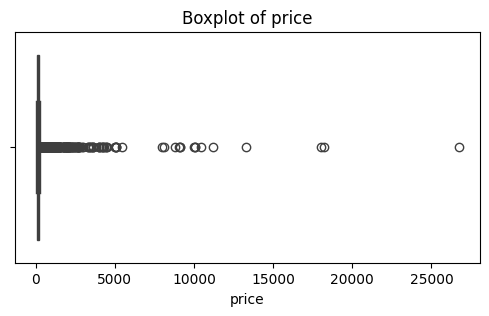

Skewness of price: 36.39
Number of outliers in price: 2763



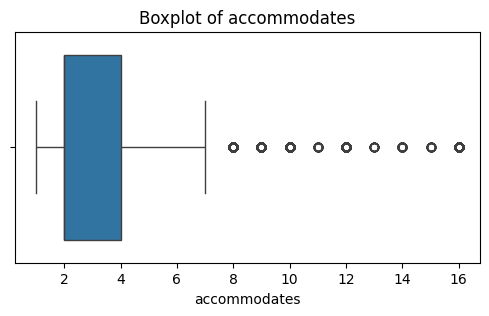

Skewness of accommodates: 2.00
Number of outliers in accommodates: 2013



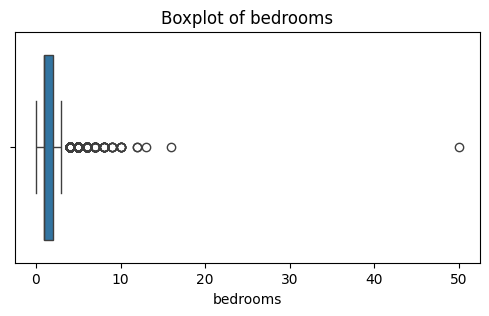

Skewness of bedrooms: 4.79
Number of outliers in bedrooms: 1577



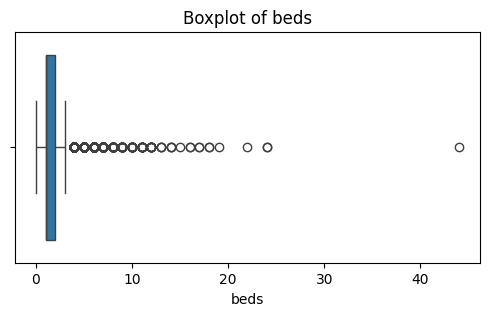

Skewness of beds: 3.81
Number of outliers in beds: 2618



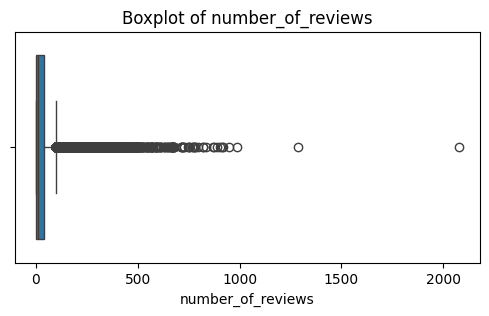

Skewness of number_of_reviews: 5.00
Number of outliers in number_of_reviews: 3555



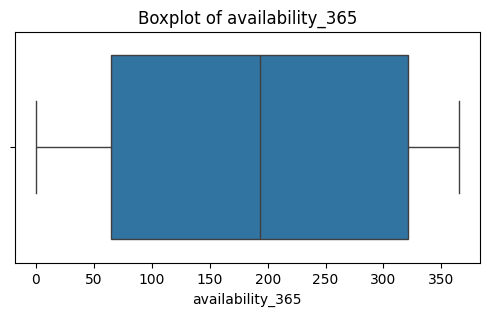

Skewness of availability_365: -0.11
Number of outliers in availability_365: 0



In [76]:
#Focus on numeric columns
numeric_columns = [
    'price', 'accommodates', 'bedrooms', 'beds','number_of_reviews', 'availability_365']

#Identify Outliers using Box Plots and Interquartile Range
for col in numeric_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_listings[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

    # Skewness
    skew = df_listings[col].skew()
    print(f"Skewness of {col}: {skew:.2f}")

    # Outlier calculation
    Q1 = df_listings[col].quantile(0.25)
    Q3 = df_listings[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df_listings[
        (df_listings[col] < Q1 - 1.5 * IQR) |
        (df_listings[col] > Q3 + 1.5 * IQR)]

    print(f"Number of outliers in {col}: {len(outliers)}\n")

# **9. Handle Skewness in Price using Log Transformation**

Skewness Value of Price = 36.39

Log transformation is applied to reduce skewness in price.

Check the log transformation:

0   5
1   5
2   5
3   4
4   5
Name: log price, dtype: float64

Log-transformed skewness = 0.66


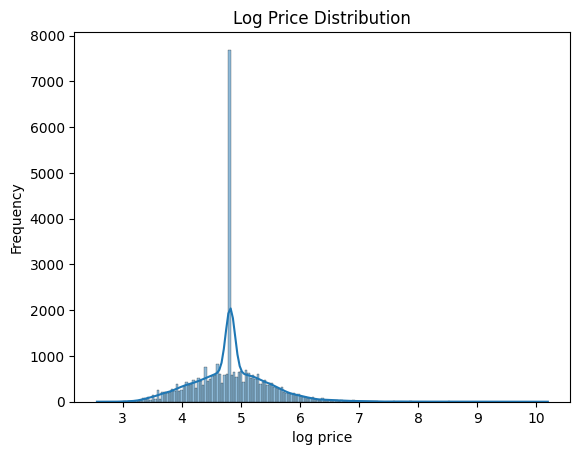

In [77]:
#Check skewness
print(f"""Skewness Value of Price = {df_listings['price'].skew():.2f}

Log transformation is applied to reduce skewness in price.
""")

#Log transform
df_listings['log price'] = np.log1p(df_listings['price'])

#Check results
print("Check the log transformation:\n")
print(df_listings['log price'].head())
print(f"\nLog-transformed skewness = {df_listings['log price'].skew():.2f}")

#Plot Result
sns.histplot(df_listings['log price'], kde=True)
plt.title("Log Price Distribution")
plt.ylabel("Frequency")
plt.show()

# **10. Manual Univariate Analysis with Focus on Skewness for Remaining Features**

UNIVARATE ANALYSIS OF DISTRIBUTION AND SKEWNESS:

To interpret skewness values, we say a skewness value that is:
• Close or equal to 0 shows highly symmetrical data. The mean is close or equal to the median. The left and right tails are balanced.
The data points are evenly distributed, and any outliers occur with the same frequency and distance on both high and low ends.

• > 1 is strongly right-skewed. The mean > median. The tail is on the right.
Most data points are heavily concentrated at the left (lower end), while outliers pull the tail to the right (higher end).

• < -1 is strongly left-skewed. The mean < median. The tail is on the left.
Most data points are heavily concentrated at the right (higher end), while outliers pull the tail to the left (lower end).

Skewness of log price: 0.66


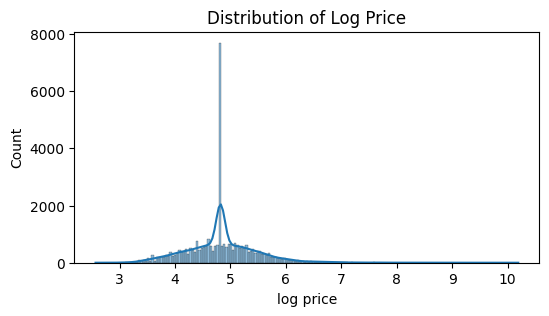

Skewness of accommodates: 2.00


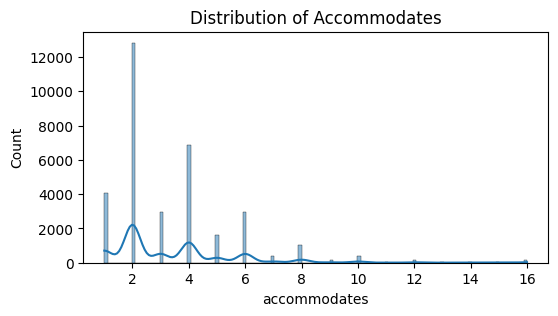

Skewness of bedrooms: 4.79


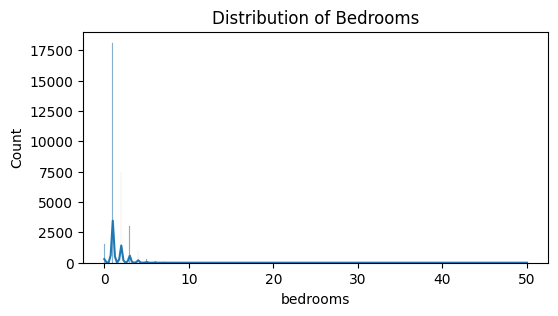

Skewness of beds: 3.81


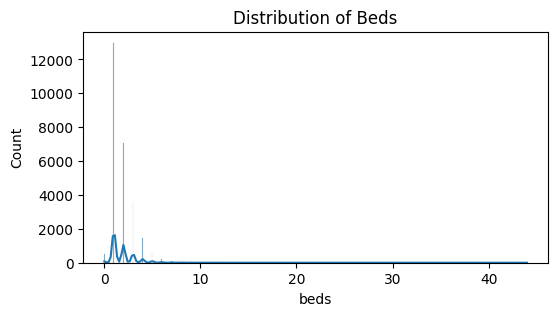

Skewness of reviews_per_month: 5.04


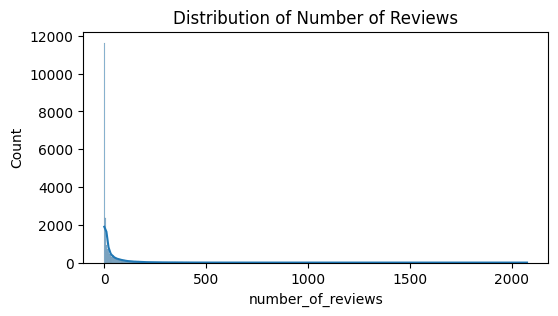

Skewness of availability_365: -0.11


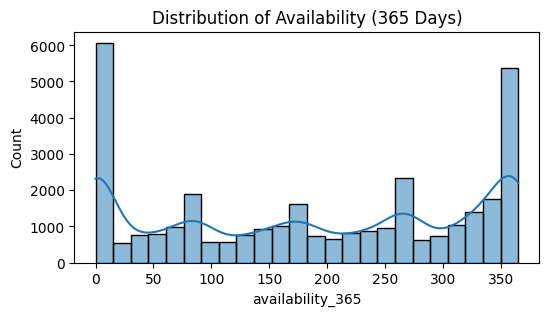

Skewness of city_code: 1.14


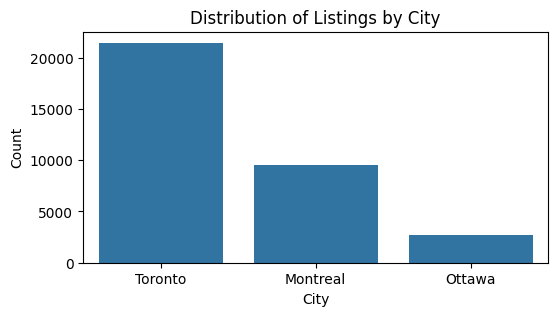

In [78]:
#Manual Univarate Analsys with Focus on Skewness for Remaining Features
print(f"""UNIVARATE ANALYSIS OF DISTRIBUTION AND SKEWNESS:

To interpret skewness values, we say a skewness value that is:
• Close or equal to 0 shows highly symmetrical data. The mean is close or equal to the median. The left and right tails are balanced.
The data points are evenly distributed, and any outliers occur with the same frequency and distance on both high and low ends.

• > 1 is strongly right-skewed. The mean > median. The tail is on the right.
Most data points are heavily concentrated at the left (lower end), while outliers pull the tail to the right (higher end).

• < -1 is strongly left-skewed. The mean < median. The tail is on the left.
Most data points are heavily concentrated at the right (higher end), while outliers pull the tail to the left (lower end).
""")

# LOG PRICE
print(f"Skewness of log price: {df_listings['log price'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.histplot(df_listings['log price'], kde=True)
plt.title("Distribution of Log Price")
plt.show()

# ACCOMMODATES
print(f"Skewness of accommodates: {df_listings['accommodates'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.histplot(df_listings['accommodates'], kde=True)
plt.title("Distribution of Accommodates")
plt.show()

# BEDROOMS
print(f"Skewness of bedrooms: {df_listings['bedrooms'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.histplot(df_listings['bedrooms'], kde=True)
plt.title("Distribution of Bedrooms")
plt.show()

# BEDS
print(f"Skewness of beds: {df_listings['beds'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.histplot(df_listings['beds'], kde=True)
plt.title("Distribution of Beds")
plt.show()

# NUMBER OF REVIEWS
print(f"Skewness of reviews_per_month: {df_listings['reviews_per_month'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.histplot(df_listings['number_of_reviews'], kde=True)
plt.title("Distribution of Number of Reviews")
plt.show()

# AVAILABILITY
print(f"Skewness of availability_365: {df_listings['availability_365'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.histplot(df_listings['availability_365'], kde=True)
plt.title("Distribution of Availability (365 Days)")
plt.show()

#City (non-encoded version)
#The distribution below is reflecting the proportion of listings across cities.
print(f"Skewness of city_code: {df_listings['city_code'].skew():.2f}")

plt.figure(figsize=(6, 3))
sns.countplot(x=df_listings['city'])
plt.title("Distribution of Listings by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

# **11. Bivariate Analysis: Correlation Matrix**

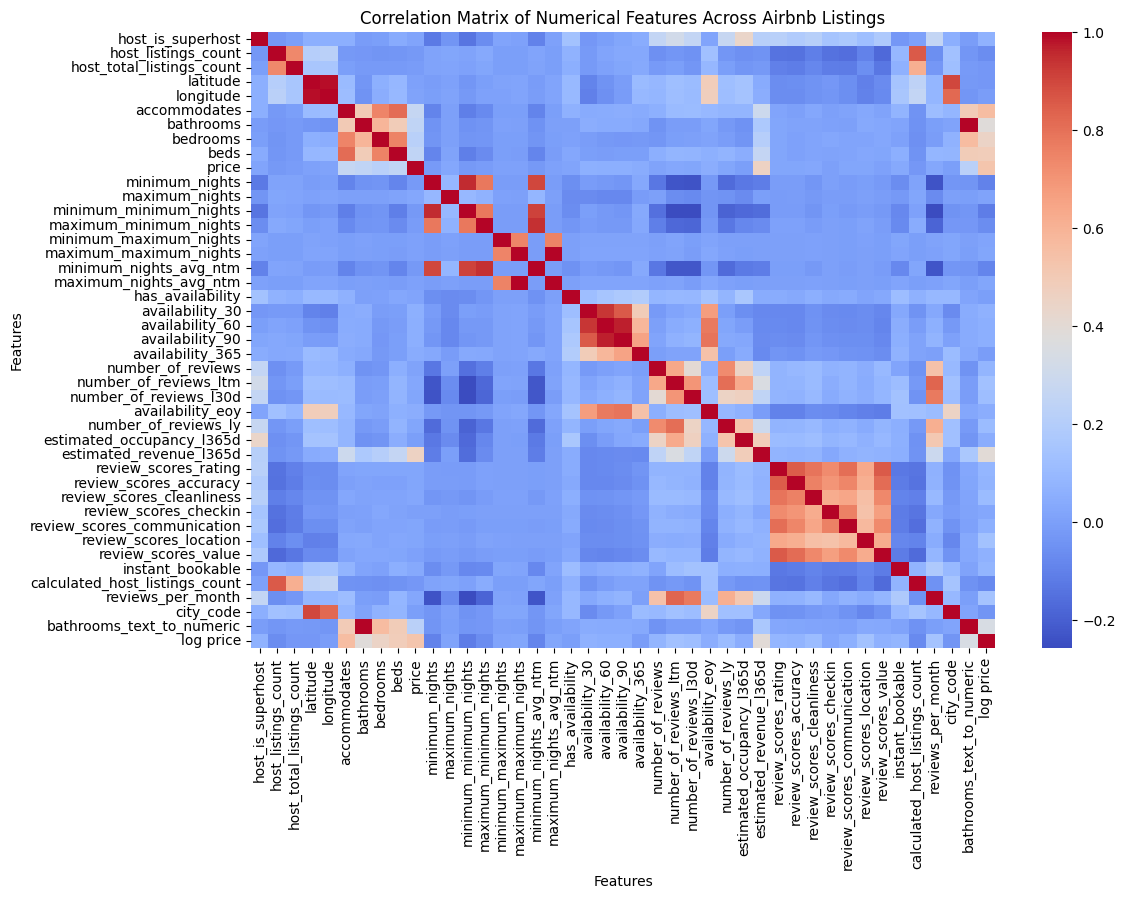

In [79]:
#Bivarate Analysis using Correlation Matrix
plt.figure(figsize=(12, 8))

sns.heatmap(df_listings.corr(numeric_only=True),
    cmap='coolwarm',)

plt.title("Correlation Matrix of Numerical Features Across Airbnb Listings")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

# **12. Feature Selection: Drop Redundant or Features with Low Explanatory Power**

In [80]:
extra_cols_to_drop = [
    'price', #Redundant to log-price
    'beds', #Redundant to accommodates (# of people the property accommodates)
    'host_has_profile_pic', #Low value due to low variance
    'host_identity_verified', #Low value due to low variance

    #Redundant to overall review_scores_rating
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',

    #Redundant to Availability_365
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_eoy',

    #Redundant to host_listings_count
    'host_total_listings_count',
    'calculated_host_listings_count',

    #Redundant to minimum_nights or maximum_nights
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',

    #Redundant to reviews_per_month
    'number_of_reviews',
    'number_of_reviews_l30d',
    'number_of_reviews_ltm',
    'number_of_reviews_ly',

    #Redundant to bathrooms_text_to_numeric
    'bathrooms',
    'bathrooms_text',

    #Redundant to neighbourhood_cleansed
    'neighbourhood',
    'neighbourhood_group_cleansed']

df_listings = df_listings.drop(columns=extra_cols_to_drop, errors='ignore')

print(f"""We have dropped the following columns during feature selection, due to their redundancy, low variance, or low explanatory power:
{extra_cols_to_drop}""")

We have dropped the following columns during feature selection, due to their redundancy, low variance, or low explanatory power:
['price', 'beds', 'host_has_profile_pic', 'host_identity_verified', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'availability_30', 'availability_60', 'availability_90', 'availability_eoy', 'host_total_listings_count', 'calculated_host_listings_count', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'number_of_reviews', 'number_of_reviews_l30d', 'number_of_reviews_ltm', 'number_of_reviews_ly', 'bathrooms', 'bathrooms_text', 'neighbourhood', 'neighbourhood_group_cleansed']


# **11. Rerun Bivariate Analysis: Correlation Matrix**

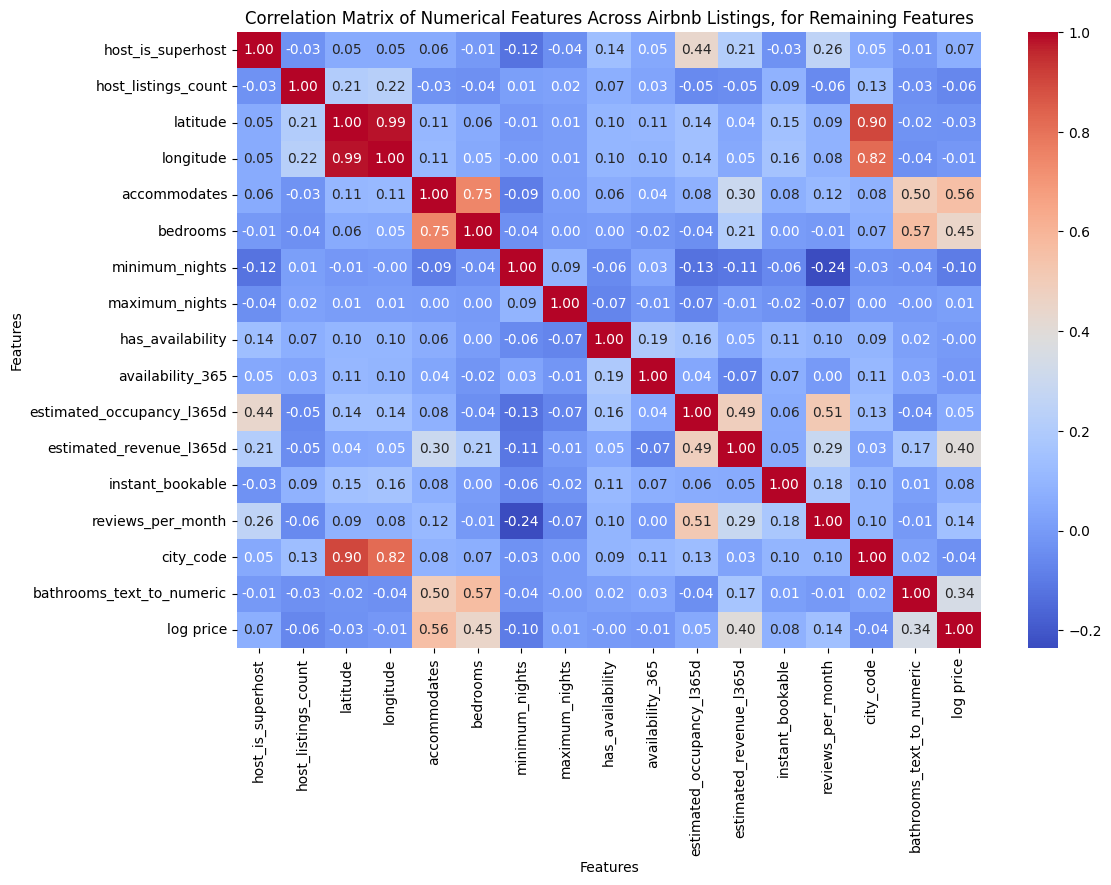

In [81]:
#Bivarate Analysis using Correlation Matrix
plt.figure(figsize=(12, 8))

sns.heatmap(df_listings.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt=".2f")

plt.title("Correlation Matrix of Numerical Features Across Airbnb Listings, for Remaining Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()